In [ ]:
from pathlib import Path
import pandas as pd
import seaborn as sns
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import ttest_ind

### Pre EDA

===== CLASS DISTRIBUTION =====
  class  count  percentage
0    ai   3241    7.574554
1  real  39547   92.425446

Total images: 42788
Class ratio (Real/AI): 12.20


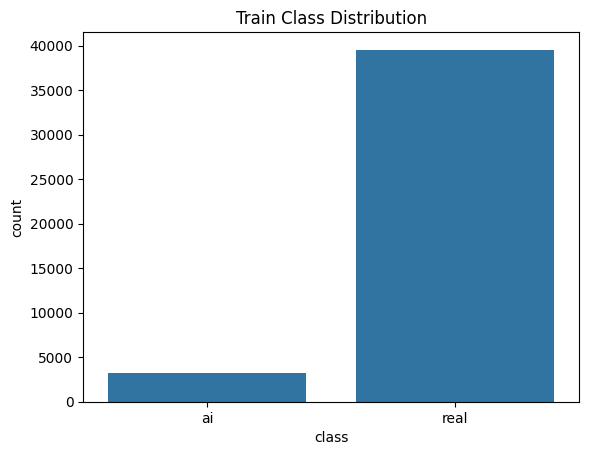

In [19]:
PROJECT_ROOT = Path().resolve().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "interim" / "train"

counts = []

for cls in ["ai", "real"]:
    n = len(list((TRAIN_PATH / cls).glob("*")))
    counts.append({"class": cls, "count": n})

df_counts = pd.DataFrame(counts)

# Estadísticas numéricas
total_images = df_counts["count"].sum()
df_counts["percentage"] = df_counts["count"] / total_images * 100

print("===== CLASS DISTRIBUTION =====")
print(df_counts)
print(f"\nTotal images: {total_images}")
print(f"Class ratio (Real/AI): {df_counts.iloc[1]['count'] / df_counts.iloc[0]['count']:.2f}")

# Gráfico
sns.barplot(data=df_counts, x="class", y="count")
plt.title("Train Class Distribution")
plt.show()

===== IMAGE SIZE STATS =====
       width                height               
        mean  std  min  max   mean  std  min  max
class                                            
ai     256.0  0.0  256  256  256.0  0.0  256  256
real   178.0  0.0  178  178  218.0  0.0  218  218


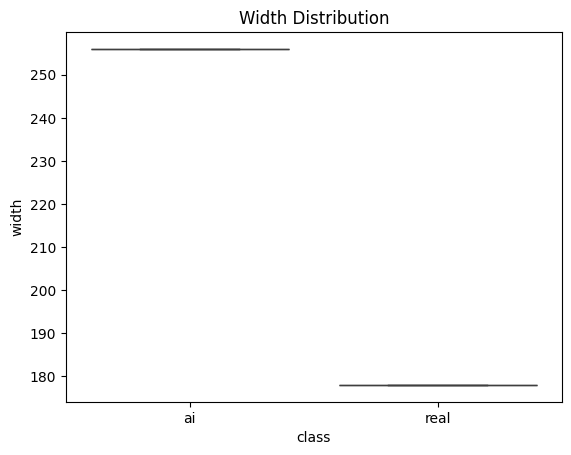

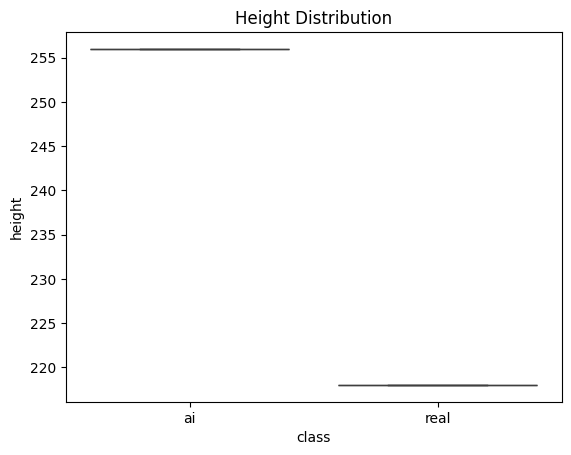

In [29]:


sizes = []

for cls in ["ai", "real"]:
    for img_path in list((TRAIN_PATH / cls).glob("*"))[:1000]:
        with Image.open(img_path) as img:
            sizes.append({
                "class": cls,
                "width": img.width,
                "height": img.height
            })

df_sizes = pd.DataFrame(sizes)

print("===== IMAGE SIZE STATS =====")
print(df_sizes.groupby("class").agg(["mean","std","min","max"]))

plt.figure()
sns.boxplot(data=df_sizes, x="class", y="width")
plt.title("Width Distribution")
plt.show()

plt.figure()
sns.boxplot(data=df_sizes, x="class", y="height")
plt.title("Height Distribution")
plt.show()

===== BRIGHTNESS STATS =====
        count      mean       std       min       25%       50%       75%  \
class                                                                       
ai     1000.0  0.539631  0.068177  0.271690  0.498824  0.545990  0.588224   
real   1000.0  0.444779  0.139302  0.093352  0.339031  0.440377  0.549745   

            max  
class            
ai     0.712647  
real   0.841852  


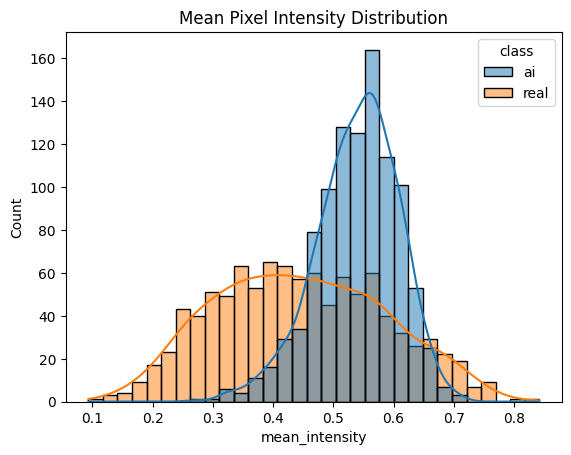

In [24]:
brightness = []

for cls in ["ai", "real"]:
    for img_path in list((TRAIN_PATH / cls).glob("*"))[:1000]:
        with Image.open(img_path) as img:
            img = np.array(img) / 255.0
            brightness.append({
                "class": cls,
                "mean_intensity": img.mean()
            })

df_brightness = pd.DataFrame(brightness)

print("===== BRIGHTNESS STATS =====")
print(df_brightness.groupby("class")["mean_intensity"].describe())

sns.histplot(data=df_brightness, x="mean_intensity", hue="class", kde=True)
plt.title("Mean Pixel Intensity Distribution")
plt.show()

===== VARIANCE STATS =====
        count      mean       std       min       25%       50%       75%  \
class                                                                       
ai     1000.0  0.057659  0.016067  0.015949  0.045765  0.057453  0.069549   
real   1000.0  0.070447  0.026871  0.013076  0.050237  0.067482  0.085540   

            max  
class            
ai     0.104605  
real   0.194758  


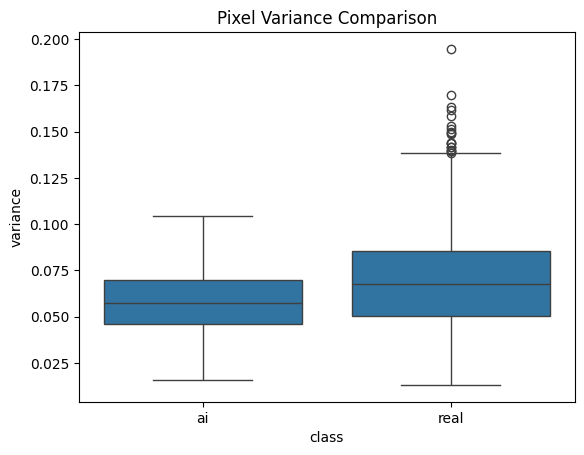

In [25]:
variance = []

for cls in ["ai", "real"]:
    for img_path in list((TRAIN_PATH / cls).glob("*"))[:1000]:
        with Image.open(img_path) as img:
            img = np.array(img) / 255.0
            variance.append({
                "class": cls,
                "variance": img.var()
            })

df_var = pd.DataFrame(variance)

print("===== VARIANCE STATS =====")
print(df_var.groupby("class")["variance"].describe())

sns.boxplot(data=df_var, x="class", y="variance")
plt.title("Pixel Variance Comparison")
plt.show()

===== RGB CHANNEL STATS =====
         r_mean              g_mean              b_mean          
           mean       std      mean       std      mean       std
class                                                            
ai     0.614145  0.063431  0.525212  0.066436  0.478235  0.071414
real   0.510493  0.141807  0.433008  0.138844  0.392458  0.142923


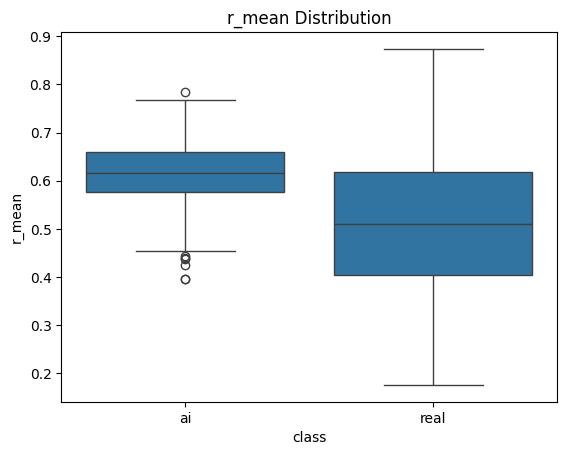

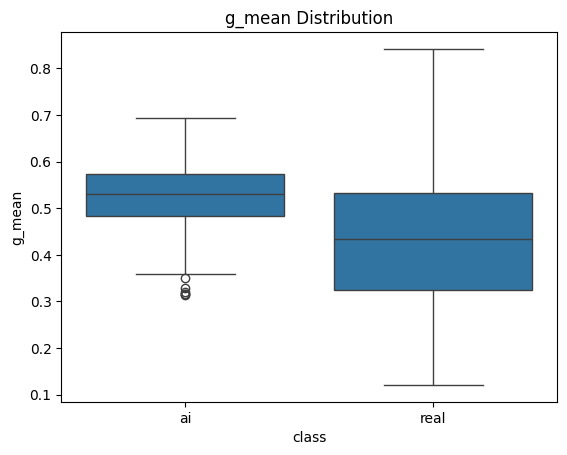

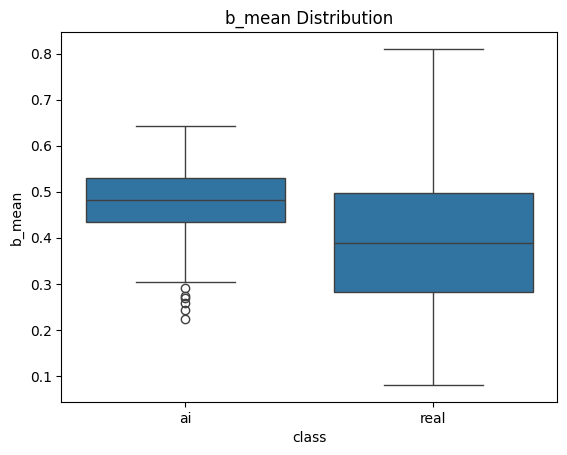

In [26]:
rgb_stats = []

for cls in ["ai", "real"]:
    for img_path in list((TRAIN_PATH / cls).glob("*"))[:500]:
        with Image.open(img_path) as img:
            img = np.array(img) / 255.0
            
            rgb_stats.append({
                "class": cls,
                "r_mean": img[:,:,0].mean(),
                "g_mean": img[:,:,1].mean(),
                "b_mean": img[:,:,2].mean()
            })

df_rgb = pd.DataFrame(rgb_stats)

print("===== RGB CHANNEL STATS =====")
print(df_rgb.groupby("class").agg(["mean","std"]))

for channel in ["r_mean","g_mean","b_mean"]:
    sns.boxplot(data=df_rgb, x="class", y=channel)
    plt.title(f"{channel} Distribution")
    plt.show()

In [ ]:


ai_vals = df_brightness[df_brightness["class"]=="ai"]["mean_intensity"]
real_vals = df_brightness[df_brightness["class"]=="real"]["mean_intensity"]

t_stat, p_val = ttest_ind(ai_vals, real_vals)

print("===== T-TEST BRIGHTNESS =====")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.6f}")

===== T-TEST BRIGHTNESS =====
T-statistic: 19.3402
P-value: 0.000000


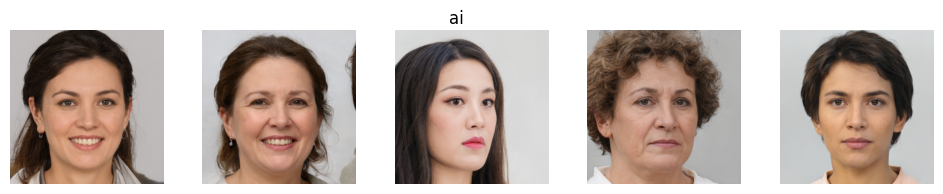

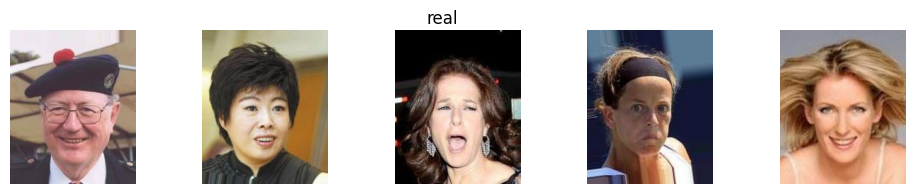

In [ ]:

def show_samples(cls):
    imgs = list((TRAIN_PATH / cls).glob("*"))
    samples = random.sample(imgs, 5)
    
    plt.figure(figsize=(12,2))
    for i, img_path in enumerate(samples):
        plt.subplot(1,5,i+1)
        plt.imshow(Image.open(img_path))
        plt.axis("off")
    plt.suptitle(cls)
    plt.show()

show_samples("ai")
show_samples("real")

### Preprocessed

### EDA